In [2]:
import tensorflow as tf
import numpy as np
import os
import json
import random
import time
from collections import Counter

!pip install editdistance -q
import editdistance

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH     = '/content/drive/MyDrive/multilingual_g2p_clustered.txt'
SAVE_DIR      = '/content/drive/MyDrive'
BASELINE_PATH = '/content/drive/MyDrive/best_g2p_transformer.weights.h5'

WEIGHTS_SAVE  = os.path.join(SAVE_DIR, 'g2p_clustered_model.weights.h5')
CURVES_SAVE   = os.path.join(SAVE_DIR, 'training_curves.png')
TOKENIZER_SRC = os.path.join(SAVE_DIR, 'src_tokenizer_clustered.json')
TOKENIZER_TGT = os.path.join(SAVE_DIR, 'tgt_tokenizer_clustered.json')

print(f'Dataset path: {DATA_PATH}')
print(f'File exists: {os.path.exists(DATA_PATH)}')

Mounted at /content/drive
Dataset path: /content/drive/MyDrive/multilingual_g2p_clustered.txt
File exists: True


In [4]:
def load_dataset(file_path):
    src_sentences = []
    tgt_sentences = []

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) != 2:
                continue

            src_str = parts[0].strip()
            tgt_str = parts[1].strip()

            if src_str.startswith('<') and '>' in src_str:
                end_idx = src_str.index('>')
                lang_tag = src_str[:end_idx+1]
                word = src_str[end_idx+1:].strip()
            else:
                lang_tag = '<UNK>'
                word = src_str

            src_seq = [lang_tag] + list(word)
            tgt_seq = tgt_str.split()

            src_sentences.append(src_seq)
            tgt_sentences.append(tgt_seq)

    return src_sentences, tgt_sentences


class Tokenizer:
    def __init__(self):
        self.pad_token = '<pad>'
        self.unk_token = '<unk>'
        self.sos_token = '<sos>'
        self.eos_token = '<eos>'
        self.s2i = {self.pad_token: 0, self.unk_token: 1, self.sos_token: 2, self.eos_token: 3}
        self.i2s = {0: self.pad_token, 1: self.unk_token, 2: self.sos_token, 3: self.eos_token}
        self.vocab_size = 4

    def fit(self, sentences):
        for sentence in sentences:
            for token in sentence:
                if token not in self.s2i:
                    self.s2i[token] = self.vocab_size
                    self.i2s[self.vocab_size] = token
                    self.vocab_size += 1

    def encode(self, sentence, add_special=True):
        encoded = [self.s2i.get(tok, self.s2i[self.unk_token]) for tok in sentence]
        if add_special:
            encoded = [self.s2i[self.sos_token]] + encoded + [self.s2i[self.eos_token]]
        return encoded

    def decode(self, indices, remove_special=True):
        special = {self.pad_token, self.sos_token, self.eos_token}
        result = []
        for idx in indices:
            tok = self.i2s.get(int(idx), self.unk_token)
            if remove_special and tok in special:
                continue
            result.append(tok)
        return result

    def save(self, path):
        with open(path, 'w', encoding='utf-8') as f:
            json.dump({
                's2i': self.s2i,
                'i2s': {int(k): v for k, v in self.i2s.items()},
                'vocab_size': self.vocab_size
            }, f, ensure_ascii=False)

    @classmethod
    def load(cls, path):
        tok = cls()
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        tok.s2i = data['s2i']
        tok.i2s = {int(k): v for k, v in data['i2s'].items()}
        tok.vocab_size = data['vocab_size']
        return tok


src_sentences, tgt_sentences = load_dataset(DATA_PATH)
print(f"Total samples: {len(src_sentences)}")
print(f"Example source: {src_sentences[0]}")
print(f"Example target: {tgt_sentences[0]}")

unique_targets = set()
for seq in tgt_sentences[:1000]:
    unique_targets.update(seq)
print(f"\nTarget vocabulary preview: {sorted(unique_targets)}")
print(f"Target vocab size (unique tokens): {len(unique_targets)}")

Total samples: 54753
Example source: ['<HI>', 'अ', 'ँ', 'ग']
Example target: ['C0', 'C23', 'C13', 'C0']

Target vocabulary preview: ['C0', 'C1', 'C10', 'C11', 'C12', 'C13', 'C14', 'C15', 'C16', 'C17', 'C19', 'C2', 'C20', 'C21', 'C22', 'C23', 'C24', 'C25', 'C26', 'C27', 'C28', 'C29', 'C3', 'C30', 'C31', 'C32', 'C33', 'C34', 'C35', 'C36', 'C37', 'C38', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']
Target vocab size (unique tokens): 38


In [5]:
random.seed(42)
indices = list(range(len(src_sentences)))
random.shuffle(indices)

train_size = int(len(indices) * 0.8)
val_size = int(len(indices) * 0.1)

train_idx = indices[:train_size]
val_idx = indices[train_size:train_size + val_size]
test_idx = indices[train_size + val_size:]

train_src = [src_sentences[i] for i in train_idx]
train_tgt = [tgt_sentences[i] for i in train_idx]
val_src   = [src_sentences[i] for i in val_idx]
val_tgt   = [tgt_sentences[i] for i in val_idx]
test_src  = [src_sentences[i] for i in test_idx]
test_tgt  = [tgt_sentences[i] for i in test_idx]

print(f"Train: {len(train_src)} | Val: {len(val_src)} | Test: {len(test_src)}")

src_tokenizer = Tokenizer()
src_tokenizer.fit(train_src)
tgt_tokenizer = Tokenizer()
tgt_tokenizer.fit(train_tgt)

print(f"Source vocab size: {src_tokenizer.vocab_size}")
print(f"Target vocab size: {tgt_tokenizer.vocab_size}")
print(f"Target tokens: {list(tgt_tokenizer.s2i.keys())}")

Train: 43802 | Val: 5475 | Test: 5476
Source vocab size: 140
Target vocab size: 43
Target tokens: ['<pad>', '<unk>', '<sos>', '<eos>', 'C30', 'C0', 'C15', 'C7', 'C38', 'C24', 'C36', 'C29', 'C25', 'C1', 'C11', 'C37', 'C16', 'C31', 'C22', 'C32', 'C18', 'C23', 'C33', 'C19', 'C9', 'C28', 'C34', 'C3', 'C8', 'C20', 'C17', 'C5', 'C21', 'C13', 'C12', 'C2', 'C26', 'C4', 'C14', 'C35', 'C6', 'C27', 'C10']


In [6]:
def encode_and_pad(src_sents, tgt_sents, src_tok, tgt_tok):
    src_encoded = [src_tok.encode(s) for s in src_sents]
    tgt_encoded = [tgt_tok.encode(t) for t in tgt_sents]
    src_padded = tf.keras.preprocessing.sequence.pad_sequences(src_encoded, padding='post', value=0)
    tgt_padded = tf.keras.preprocessing.sequence.pad_sequences(tgt_encoded, padding='post', value=0)
    return src_padded, tgt_padded

train_src_enc, train_tgt_enc = encode_and_pad(train_src, train_tgt, src_tokenizer, tgt_tokenizer)
val_src_enc, val_tgt_enc     = encode_and_pad(val_src, val_tgt, src_tokenizer, tgt_tokenizer)
test_src_enc, test_tgt_enc   = encode_and_pad(test_src, test_tgt, src_tokenizer, tgt_tokenizer)

print(f"Train src: {train_src_enc.shape}, tgt: {train_tgt_enc.shape}")
print(f"Val   src: {val_src_enc.shape},   tgt: {val_tgt_enc.shape}")
print(f"Test  src: {test_src_enc.shape},  tgt: {test_tgt_enc.shape}")

Train src: (43802, 23), tgt: (43802, 31)
Val   src: (5475, 26),   tgt: (5475, 35)
Test  src: (5476, 22),  tgt: (5476, 27)


In [7]:
BATCH_SIZE = 64
BUFFER_SIZE = 20000

def make_dataset(src, tgt, batch_size, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((src, tgt))
    if shuffle:
        ds = ds.shuffle(BUFFER_SIZE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_src_enc, train_tgt_enc, BATCH_SIZE, shuffle=True)
val_ds   = make_dataset(val_src_enc, val_tgt_enc, BATCH_SIZE)
test_ds  = make_dataset(test_src_enc, test_tgt_enc, BATCH_SIZE)

for src_batch, tgt_batch in train_ds.take(1):
    print(f"Source batch: {src_batch.shape}")
    print(f"Target batch: {tgt_batch.shape}")

Source batch: (64, 23)
Target batch: (64, 31)


In [8]:
def get_positional_encoding(max_len, d_model):
    positions = np.arange(max_len)[:, np.newaxis]
    dims = np.arange(d_model)[np.newaxis, :]
    angles = positions / np.power(10000, (2 * (dims // 2)) / d_model)
    angles[:, 0::2] = np.sin(angles[:, 0::2])
    angles[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(angles[np.newaxis, :, :], dtype=tf.float32)

def create_padding_mask(seq):
    mask = tf.cast(tf.math.equal(seq, 0), tf.float32)
    return mask[:, tf.newaxis, tf.newaxis, :]

def create_look_ahead_mask(size):
    mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
    return mask

def create_masks(src, tgt):
    enc_padding_mask = create_padding_mask(src)
    dec_padding_mask = create_padding_mask(src)
    look_ahead_mask = create_look_ahead_mask(tf.shape(tgt)[1])
    dec_target_padding_mask = create_padding_mask(tgt)
    combined_mask = tf.maximum(dec_target_padding_mask, look_ahead_mask)
    return enc_padding_mask, combined_mask, dec_padding_mask

def scaled_dot_product_attention(q, k, v, mask):
    matmul_qk = tf.matmul(q, k, transpose_b=True)
    dk = tf.cast(tf.shape(k)[-1], tf.float32)
    scaled = matmul_qk / tf.math.sqrt(dk)
    if mask is not None:
        scaled += (mask * -1e9)
    weights = tf.nn.softmax(scaled, axis=-1)
    output = tf.matmul(weights, v)
    return output

class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.d_model = d_model
        assert d_model % num_heads == 0
        self.depth = d_model // num_heads
        self.wq = tf.keras.layers.Dense(d_model)
        self.wk = tf.keras.layers.Dense(d_model)
        self.wv = tf.keras.layers.Dense(d_model)
        self.dense = tf.keras.layers.Dense(d_model)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs, **kwargs):
        v, k, q, mask = inputs['v'], inputs['k'], inputs['q'], inputs['mask']
        batch_size = tf.shape(q)[0]
        q = self.split_heads(self.wq(q), batch_size)
        k = self.split_heads(self.wk(k), batch_size)
        v = self.split_heads(self.wv(v), batch_size)
        output = scaled_dot_product_attention(q, k, v, mask)
        output = tf.transpose(output, perm=[0, 2, 1, 3])
        concat = tf.reshape(output, (batch_size, -1, self.d_model))
        return self.dense(concat)

def point_wise_ffn(d_model, dff):
    return tf.keras.Sequential([
        tf.keras.layers.Dense(dff, activation='relu'),
        tf.keras.layers.Dense(d_model)
    ])

class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = point_wise_ffn(d_model, dff)
        self.ln1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.ln2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(dropout_rate)
        self.dropout2 = tf.keras.layers.Dropout(dropout_rate)

    def call(self, inputs, training=False, **kwargs):
        x, mask = inputs
        attn = self.mha({'v': x, 'k': x, 'q': x, 'mask': mask})
        attn = self.dropout1(attn, training=training)
        out1 = self.ln1(x + attn)
        ffn_out = self.ffn(out1)
        ffn_out = self.dropout2(ffn_out, training=training)
        return self.ln2(out1 + ffn_out)

class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha1 = MultiHeadAttention(d_model, num_heads)
        self.mha2 = MultiHeadAttention(d_model, num_heads)
        self.ffn = point_wise_ffn(d_model, dff)
        self.ln1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.ln2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.ln3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(dropout_rate)
        self.dropout2 = tf.keras.layers.Dropout(dropout_rate)
        self.dropout3 = tf.keras.layers.Dropout(dropout_rate)

    def call(self, inputs, training=False, **kwargs):
        x, enc_output, look_ahead_mask, padding_mask = inputs
        attn1 = self.mha1({'v': x, 'k': x, 'q': x, 'mask': look_ahead_mask})
        attn1 = self.dropout1(attn1, training=training)
        out1 = self.ln1(attn1 + x)
        attn2 = self.mha2({'v': enc_output, 'k': enc_output, 'q': out1, 'mask': padding_mask})
        attn2 = self.dropout2(attn2, training=training)
        out2 = self.ln2(attn2 + out1)
        ffn_out = self.ffn(out2)
        ffn_out = self.dropout3(ffn_out, training=training)
        return self.ln3(ffn_out + out2)

class Encoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, max_pos_enc, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.embedding = tf.keras.layers.Embedding(input_vocab_size, d_model)
        self.pos_encoding = get_positional_encoding(max_pos_enc, d_model)
        self.enc_layers = [EncoderLayer(d_model, num_heads, dff, dropout_rate) for _ in range(num_layers)]
        self.dropout = tf.keras.layers.Dropout(dropout_rate)

    def call(self, inputs, training=False, **kwargs):
        x, mask = inputs
        seq_len = tf.shape(x)[1]
        x = self.embedding(x) * tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x += self.pos_encoding[:, :seq_len, :]
        x = self.dropout(x, training=training)
        for layer in self.enc_layers:
            x = layer((x, mask), training=training)
        return x

class Decoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, target_vocab_size, max_pos_enc, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.embedding = tf.keras.layers.Embedding(target_vocab_size, d_model)
        self.pos_encoding = get_positional_encoding(max_pos_enc, d_model)
        self.dec_layers = [DecoderLayer(d_model, num_heads, dff, dropout_rate) for _ in range(num_layers)]
        self.dropout = tf.keras.layers.Dropout(dropout_rate)

    def call(self, inputs, training=False, **kwargs):
        x, enc_output, look_ahead_mask, padding_mask = inputs
        seq_len = tf.shape(x)[1]
        x = self.embedding(x) * tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x += self.pos_encoding[:, :seq_len, :]
        x = self.dropout(x, training=training)
        for layer in self.dec_layers:
            x = layer((x, enc_output, look_ahead_mask, padding_mask), training=training)
        return x

class Transformer(tf.keras.Model):
    def __init__(self, num_layers, d_model, num_heads, dff,
                 input_vocab_size, target_vocab_size,
                 pe_input, pe_target, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.encoder = Encoder(num_layers, d_model, num_heads, dff,
                               input_vocab_size, pe_input, dropout_rate)
        self.decoder = Decoder(num_layers, d_model, num_heads, dff,
                               target_vocab_size, pe_target, dropout_rate)
        self.final_layer = tf.keras.layers.Dense(target_vocab_size)

    def call(self, inputs, training=False, **kwargs):
        src, tgt = inputs
        enc_padding_mask, look_ahead_mask, dec_padding_mask = create_masks(src, tgt)
        enc_output = self.encoder((src, enc_padding_mask), training=training)
        dec_output = self.decoder((tgt, enc_output, look_ahead_mask, dec_padding_mask), training=training)
        return self.final_layer(dec_output)

In [9]:
NUM_LAYERS = 3
D_MODEL = 128
NUM_HEADS = 4
DFF = 512
DROPOUT_RATE = 0.1
EPOCHS = 30

MAX_SRC_LEN = train_src_enc.shape[1] + 50
MAX_TGT_LEN = train_tgt_enc.shape[1] + 50

model = Transformer(
    num_layers=NUM_LAYERS, d_model=D_MODEL, num_heads=NUM_HEADS, dff=DFF,
    input_vocab_size=src_tokenizer.vocab_size,
    target_vocab_size=tgt_tokenizer.vocab_size,   # ← 16 tokens (vs 61 in baseline)
    pe_input=MAX_SRC_LEN, pe_target=MAX_TGT_LEN,
    dropout_rate=DROPOUT_RATE
)

print(f"Model created: {NUM_LAYERS} layers, d_model={D_MODEL}, heads={NUM_HEADS}")
print(f"Source vocab: {src_tokenizer.vocab_size}")
print(f"Target vocab: {tgt_tokenizer.vocab_size}  ← (baseline was 61, now {tgt_tokenizer.vocab_size})")

Model created: 3 layers, d_model=128, heads=4
Source vocab: 140
Target vocab: 43  ← (baseline was 61, now 43)


In [10]:
class TransformerSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=4000):
        super().__init__()
        self.d_model = tf.cast(d_model, tf.float32)
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

lr_schedule = TransformerSchedule(D_MODEL)
optimizer = tf.keras.optimizers.Adam(lr_schedule, beta_1=0.9, beta_2=0.98, epsilon=1e-9)

loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss = loss_object(real, pred)
    mask = tf.cast(mask, dtype=loss.dtype)
    loss *= mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

def accuracy_function(real, pred):
    pred_ids = tf.argmax(pred, axis=2)
    real = tf.cast(real, dtype=pred_ids.dtype)
    match = tf.cast(tf.equal(real, pred_ids), tf.float32)
    mask = tf.cast(tf.math.logical_not(tf.math.equal(real, 0)), tf.float32)
    return tf.reduce_sum(match * mask) / tf.reduce_sum(mask)

In [11]:
train_loss = tf.keras.metrics.Mean(name='train_loss')
train_accuracy = tf.keras.metrics.Mean(name='train_accuracy')

@tf.function
def train_step(src, tgt):
    tgt_input = tgt[:, :-1]
    tgt_real  = tgt[:, 1:]
    with tf.GradientTape() as tape:
        predictions = model((src, tgt_input), training=True)
        loss = loss_function(tgt_real, predictions)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    train_loss(loss)
    train_accuracy(accuracy_function(tgt_real, predictions))

@tf.function
def val_step(src, tgt):
    tgt_input = tgt[:, :-1]
    tgt_real  = tgt[:, 1:]
    predictions = model((src, tgt_input), training=False)
    return loss_function(tgt_real, predictions)


history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'epoch_time': [],
}

best_val_loss = float('inf')
patience = 5
patience_counter = 0

print(f"\n{'='*60}")
print(f"TRAINING CLUSTERED G2P MODEL")
print(f"{'='*60}")
print(f"Target vocab: {tgt_tokenizer.vocab_size} tokens (cluster labels)")
print(f"Epochs: {EPOCHS} | Batch size: {BATCH_SIZE} | Patience: {patience}")
print(f"{'='*60}\n")

training_start = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()
    train_loss.reset_state()
    train_accuracy.reset_state()

    for batch, (src, tgt) in enumerate(train_ds):
        train_step(src, tgt)

    val_losses = []
    for src, tgt in val_ds:
        v_loss = val_step(src, tgt)
        val_losses.append(v_loss.numpy())
    avg_val_loss = np.mean(val_losses)

    epoch_time = time.time() - epoch_start

    history['train_loss'].append(float(train_loss.result()))
    history['train_acc'].append(float(train_accuracy.result()))
    history['val_loss'].append(float(avg_val_loss))
    history['epoch_time'].append(epoch_time)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss.result():.4f} | "
          f"Train Acc: {train_accuracy.result():.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Time: {epoch_time:.1f}s")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        model.save_weights(WEIGHTS_SAVE)
        print(f"  -> Best model saved! (val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

total_time = time.time() - training_start
print(f"\nTraining complete! Total time: {total_time/60:.1f} minutes")
print(f"Best val loss: {best_val_loss:.4f}")

history_path = os.path.join(SAVE_DIR, 'clustered_training_history.json')
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f"Training history saved: {history_path}")


TRAINING CLUSTERED G2P MODEL
Target vocab: 43 tokens (cluster labels)
Epochs: 30 | Batch size: 64 | Patience: 5

Epoch 01/30 | Train Loss: 1.5523 | Train Acc: 0.6021 | Val Loss: 0.0817 | Time: 64.0s
  -> Best model saved! (val_loss=0.0817)
Epoch 02/30 | Train Loss: 0.0842 | Train Acc: 0.9775 | Val Loss: 0.0118 | Time: 27.4s
  -> Best model saved! (val_loss=0.0118)
Epoch 03/30 | Train Loss: 0.0378 | Train Acc: 0.9905 | Val Loss: 0.0117 | Time: 25.9s
  -> Best model saved! (val_loss=0.0117)
Epoch 04/30 | Train Loss: 0.0348 | Train Acc: 0.9917 | Val Loss: 0.0086 | Time: 26.2s
  -> Best model saved! (val_loss=0.0086)
Epoch 05/30 | Train Loss: 0.0360 | Train Acc: 0.9918 | Val Loss: 0.0238 | Time: 26.0s
Epoch 06/30 | Train Loss: 0.0361 | Train Acc: 0.9920 | Val Loss: 0.0114 | Time: 41.7s
Epoch 07/30 | Train Loss: 0.0310 | Train Acc: 0.9928 | Val Loss: 0.0072 | Time: 25.8s
  -> Best model saved! (val_loss=0.0072)
Epoch 08/30 | Train Loss: 0.0260 | Train Acc: 0.9942 | Val Loss: 0.0092 | Time:


✅ Training curves saved: /content/drive/MyDrive/training_curves.png


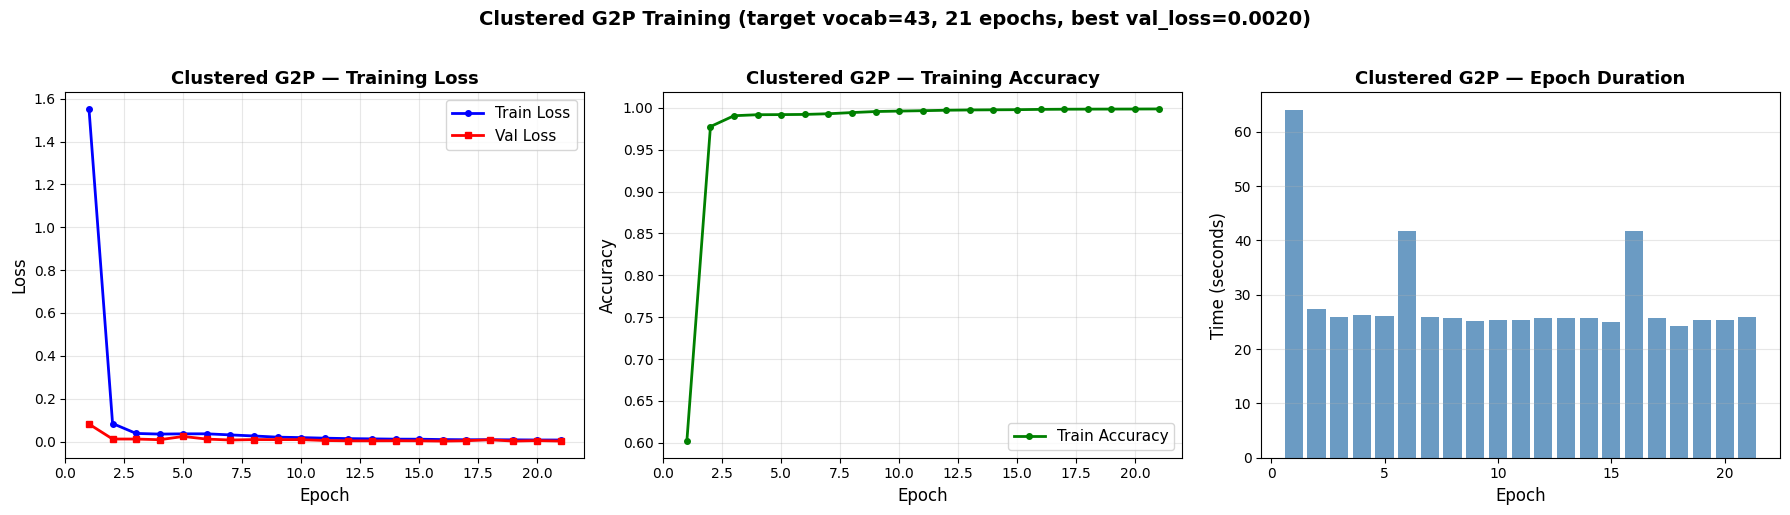

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

ax1 = axes[0]
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', markersize=4, linewidth=2)
ax1.plot(epochs_range, history['val_loss'], 'r-s', label='Val Loss', markersize=4, linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Clustered G2P — Training Loss', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(epochs_range, history['train_acc'], 'g-o', label='Train Accuracy', markersize=4, linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Clustered G2P — Training Accuracy', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

ax3 = axes[2]
ax3.bar(epochs_range, history['epoch_time'], color='steelblue', alpha=0.8)
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('Time (seconds)', fontsize=12)
ax3.set_title('Clustered G2P — Epoch Duration', fontsize=13, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

plt.suptitle(f'Clustered G2P Training (target vocab={tgt_tokenizer.vocab_size}, '
             f'{len(history["train_loss"])} epochs, best val_loss={best_val_loss:.4f})',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(CURVES_SAVE, dpi=150, bbox_inches='tight')
print(f"\n✅ Training curves saved: {CURVES_SAVE}")
plt.show()

In [13]:
model.load_weights(WEIGHTS_SAVE)
print("Loaded best model weights.")

def greedy_decode(model, src, max_len=100):
    sos_id = tgt_tokenizer.s2i[tgt_tokenizer.sos_token]
    eos_id = tgt_tokenizer.s2i[tgt_tokenizer.eos_token]
    decoder_input = tf.expand_dims([sos_id], 0)

    for _ in range(max_len):
        predictions = model((src, decoder_input), training=False)
        next_token = tf.argmax(predictions[:, -1, :], axis=-1)
        next_token = tf.cast(tf.expand_dims(next_token, 0), tf.int32)
        decoder_input = tf.concat([decoder_input, next_token], axis=-1)
        if next_token.numpy()[0][0] == eos_id:
            break

    return decoder_input.numpy()[0].tolist()


total_per = 0.0
total_wer = 0.0
num_samples = 0

print(f"\nEvaluating on {len(test_src_enc)} test samples...")
print("-" * 60)

for i in range(len(test_src_enc)):
    src_input = tf.expand_dims(test_src_enc[i], 0)
    predicted_ids = greedy_decode(model, src_input, max_len=50)

    pred_tokens = tgt_tokenizer.decode(predicted_ids, remove_special=True)
    true_tokens = tgt_tokenizer.decode(test_tgt_enc[i].tolist(), remove_special=True)

    per = editdistance.eval(pred_tokens, true_tokens) / max(len(true_tokens), 1)
    total_per += per

    wer = 0.0 if pred_tokens == true_tokens else 1.0
    total_wer += wer
    num_samples += 1

    if i < 10:
        src_decoded = src_tokenizer.decode(test_src_enc[i].tolist(), remove_special=True)
        print(f"Input:     {''.join(src_decoded)}")
        print(f"Predicted: {' '.join(pred_tokens)}")
        print(f"Expected:  {' '.join(true_tokens)}")
        print(f"PER: {per:.4f}")
        print('-' * 50)

    if (i + 1) % 500 == 0:
        print(f"  Progress: {i+1}/{len(test_src_enc)} samples evaluated...")

avg_per = total_per / num_samples
avg_wer = total_wer / num_samples

print(f"\n{'='*60}")
print(f"CLUSTERED MODEL RESULTS ON TEST SET ({num_samples} samples)")
print(f"{'='*60}")
print(f"Phoneme Error Rate (PER): {avg_per:.4f} ({avg_per*100:.2f}%)")
print(f"Word Error Rate   (WER):  {avg_wer:.4f} ({avg_wer*100:.2f}%)")
print(f"Target Vocab Size:        {tgt_tokenizer.vocab_size}")
print(f"{'='*60}")

Loaded best model weights.

Evaluating on 5476 test samples...
------------------------------------------------------------
Input:     <MR>ना
Predicted: C24 C0 C1
Expected:  C24 C0 C1
PER: 0.0000
--------------------------------------------------
Input:     <GU>રંગુનવાલા
Predicted: C29 C0 C23 C13 C0 C36 C24 C0 C37 C0 C1 C21 C0 C1
Expected:  C29 C0 C23 C13 C0 C36 C24 C0 C37 C0 C1 C21 C0 C1
PER: 0.0000
--------------------------------------------------
Input:     <GU>સુહાના
Predicted: C30 C0 C36 C15 C0 C1 C24 C0 C1
Expected:  C30 C0 C36 C15 C0 C1 C24 C0 C1
PER: 0.0000
--------------------------------------------------
Input:     <MR>फिरवायचे
Predicted: C12 C0 C16 C29 C0 C37 C0 C1 C38 C0 C5 C0 C11
Expected:  C12 C0 C16 C29 C0 C37 C0 C1 C38 C0 C5 C0 C11
PER: 0.0000
--------------------------------------------------
Input:     <GU>બજેટની
Predicted: C3 C0 C17 C0 C11 C34 C0 C24 C0 C16
Expected:  C3 C0 C17 C0 C11 C34 C0 C24 C0 C16
PER: 0.0000
--------------------------------------------------


In [14]:
src_tokenizer.save(TOKENIZER_SRC)
tgt_tokenizer.save(TOKENIZER_TGT)

total_params = sum(np.prod(v.shape) for v in model.trainable_variables)
checkpoint_size = os.path.getsize(WEIGHTS_SAVE) / (1024 * 1024)

print(f"\n{'='*60}")
print(f"TRAINING SUMMARY")
print(f"{'='*60}")
print(f"  Architecture:     {NUM_LAYERS}-layer Transformer, d={D_MODEL}, heads={NUM_HEADS}")
print(f"  Source vocab:     {src_tokenizer.vocab_size}")
print(f"  Target vocab:     {tgt_tokenizer.vocab_size} (cluster labels)")
print(f"  Parameters:       {total_params:,}")
print(f"  Checkpoint size:  {checkpoint_size:.2f} MB")
print(f"  Best val loss:    {best_val_loss:.4f}")
print(f"  Training epochs:  {len(history['train_loss'])}")
print(f"  Total time:       {total_time/60:.1f} minutes")
print(f"  Test PER:         {avg_per:.4f} ({avg_per*100:.2f}%)")
print(f"  Test WER:         {avg_wer:.4f} ({avg_wer*100:.2f}%)")
print(f"\n  Saved files:")
print(f"    {WEIGHTS_SAVE}")
print(f"    {CURVES_SAVE}")
print(f"    {TOKENIZER_SRC}")
print(f"    {TOKENIZER_TGT}")
print(f"    {history_path}")
print(f"{'='*60}")


TRAINING SUMMARY
  Architecture:     3-layer Transformer, d=128, heads=4
  Source vocab:     140
  Target vocab:     43 (cluster labels)
  Parameters:       1,417,515
  Checkpoint size:  5.66 MB
  Best val loss:    0.0020
  Training epochs:  21
  Total time:       10.3 minutes
  Test PER:         0.0008 (0.08%)
  Test WER:         0.0035 (0.35%)

  Saved files:
    /content/drive/MyDrive/g2p_clustered_model.weights.h5
    /content/drive/MyDrive/training_curves.png
    /content/drive/MyDrive/src_tokenizer_clustered.json
    /content/drive/MyDrive/tgt_tokenizer_clustered.json
    /content/drive/MyDrive/clustered_training_history.json
